# Pakistan Education Analysis — ASER 2023
### Gender Gap EDA + Choropleth Map

In [1]:
#importing the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import folium
import warnings
warnings.filterwarnings('ignore')

In [2]:
#loading the clean dataset
df = pd.read_csv('D:/pakistan-education-analysis/data/aser_2023_clean.csv')
df.head()

,RNAME,DNAME,STYPE,S001,S002,S007P,S03e1,S03f1,school_gender,nonfunctional
0,AZAD JAMMU AND KASHMIR ...,BAGH,1,1,1.0,27,1.0,1.0,Boys Only,1
1,AZAD JAMMU AND KASHMIR ...,BAGH,1,2,2.0,224,1.0,1.0,Girls Only,1
2,AZAD JAMMU AND KASHMIR ...,BAGH,1,2,1.0,301,1.0,1.0,Boys Only,1
3,AZAD JAMMU AND KASHMIR ...,BAGH,1,1,1.0,33,0.0,1.0,Boys Only,0
4,AZAD JAMMU AND KASHMIR ...,BAGH,1,1,1.0,75,1.0,1.0,Boys Only,1


In [4]:
df.shape

(6095, 10)

In [5]:
df['nonfunctional'].value_counts()

nonfunctional
1    3067
0    3028
Name: count, dtype: int64

## Gender Gap Analysis

In [8]:
#checking school gender type distribution
df['school_gender'].value_counts()

school_gender
Girls Only    2710
Boys Only     2174
0              825
Mixed          386
Name: count, dtype: int64

In [7]:
#non-functional rate by school gender type
df.groupby('school_gender')['nonfunctional'].mean() * 100

school_gender
0             45.454545
Boys Only     58.463661
Girls Only    47.601476
Mixed         33.937824
Name: nonfunctional, dtype: float64

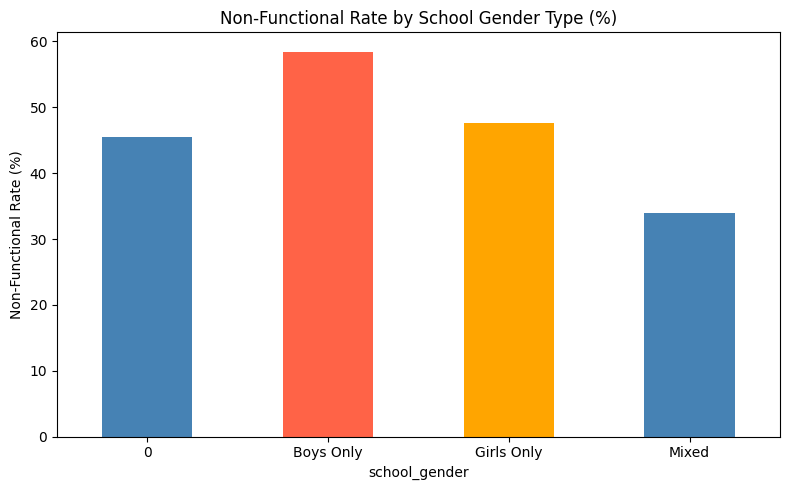

In [9]:
#plotting national gender gap
gender_rate = df.groupby('school_gender')['nonfunctional'].mean() * 100

gender_rate.plot(kind='bar', figsize=(8,5), color=['steelblue','tomato','orange'], rot=0)
plt.title('Non-Functional Rate by School Gender Type (%)')
plt.ylabel('Non-Functional Rate (%)')
plt.tight_layout()
plt.savefig('D:/pakistan-education-analysis/visuals/national_gender_gap.png', dpi=150)
plt.show()

In [10]:
#gender gap — boys vs girls only
boys_rate = df[df['school_gender']=='Boys Only']['nonfunctional'].mean() * 100
girls_rate = df[df['school_gender']=='Girls Only']['nonfunctional'].mean() * 100
print(f'Boys schools non-functional rate : {boys_rate:.1f}%')
print(f'Girls schools non-functional rate: {girls_rate:.1f}%')
print(f'Gap: {girls_rate - boys_rate:.1f} percentage points')

Boys schools non-functional rate : 58.5%
Girls schools non-functional rate: 47.6%
Gap: -10.9 percentage points


## Province Level Gender Gap

In [12]:
#gender gap by province
prov_gender = df.groupby(['RNAME','school_gender'])['nonfunctional'].mean().unstack() * 100
prov_gender

school_gender,0,Boys Only,Girls Only,Mixed
RNAME,,,,
AZAD JAMMU AND KASHMIR,60.000000,67.801858,68.613139,50.000000
BALOCHISTAN,50.000000,38.129496,30.853659,41.176471
GILGIT-BALTISTAN,68.421053,73.055556,52.222222,NaN
ISLAMABAD CAPITAL TERRITORY,0.000000,61.363636,40.000000,NaN
KHYBER PAKHTUNKHWA,34.482759,40.604027,46.314496,50.000000
PUNJAB,61.290323,66.207951,59.640103,50.000000
SINDH,34.451220,58.620690,80.303030,33.147632


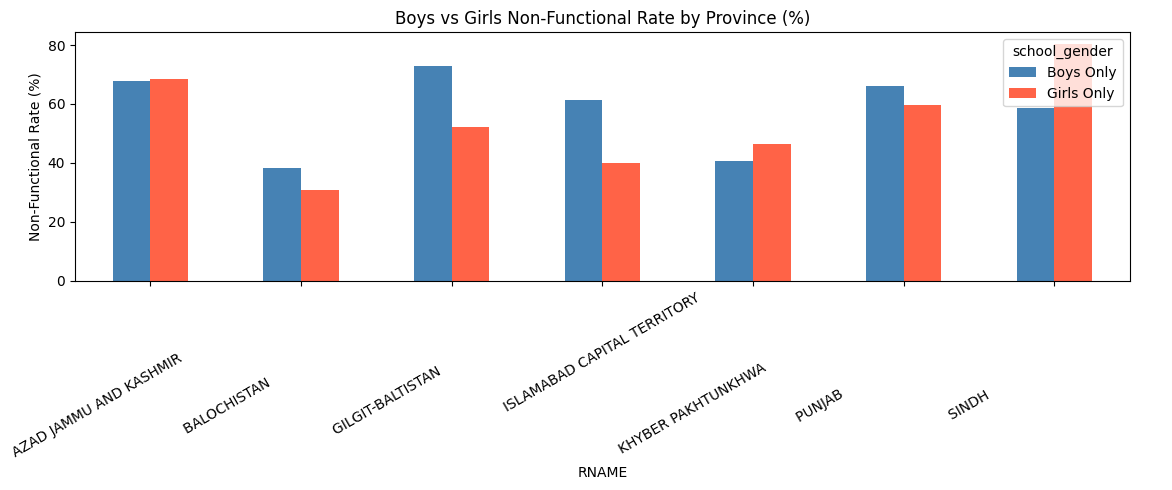

In [13]:
#plotting province level gender gap
prov_gender[['Boys Only','Girls Only']].plot(kind='bar', figsize=(12,5),
                                              color=['steelblue','tomato'], rot=30)
plt.title('Boys vs Girls Non-Functional Rate by Province (%)')
plt.ylabel('Non-Functional Rate (%)')
plt.tight_layout()
plt.savefig('D:/pakistan-education-analysis/visuals/province_gender_gap.png', dpi=150)
plt.show()

## Sindh Deep Dive

In [17]:
#filtering sindh
sindh = df[df['RNAME'].str.contains('SINDH', case=False, na=False)].copy()
print(sindh.shape)
sindh['nonfunctional'].mean() * 100

(811, 10)


np.float64(39.33415536374846)

In [20]:
#sindh gender gap
sindh.groupby('school_gender')['nonfunctional'].mean() * 100

school_gender
0             34.451220
Boys Only     58.620690
Girls Only    80.303030
Mixed         33.147632
Name: nonfunctional, dtype: float64

In [21]:
#sindh district level gender gap
sindh_dist_gender = sindh.groupby(['DNAME','school_gender'])['nonfunctional'].mean().unstack() * 100
sindh_dist_gender['gap'] = sindh_dist_gender['Girls Only'] - sindh_dist_gender['Boys Only']
sindh_dist_gender.sort_values('Girls Only', ascending=False).head(10)

school_gender,0,Boys Only,Girls Only,Mixed,gap
DNAME,,,,,
BADIN,NaN,NaN,100.000000,41.379310,NaN
GHOTKI,25.000000,NaN,100.000000,37.037037,NaN
JAMSHORO,18.518519,NaN,100.000000,0.000000,NaN
MIRPUR KHAS,30.769231,100.000000,100.000000,33.333333,0.000000
NAUSHAHRO FEROZE,NaN,0.000000,100.000000,59.259259,100.000000
SHIKARPUR,NaN,NaN,100.000000,19.354839,NaN
UMER KOT,0.000000,NaN,100.000000,14.814815,NaN
KARACHI MALIR,NaN,38.461538,89.473684,50.000000,51.012146
KARACHI WEST,NaN,62.068966,80.769231,NaN,18.700265


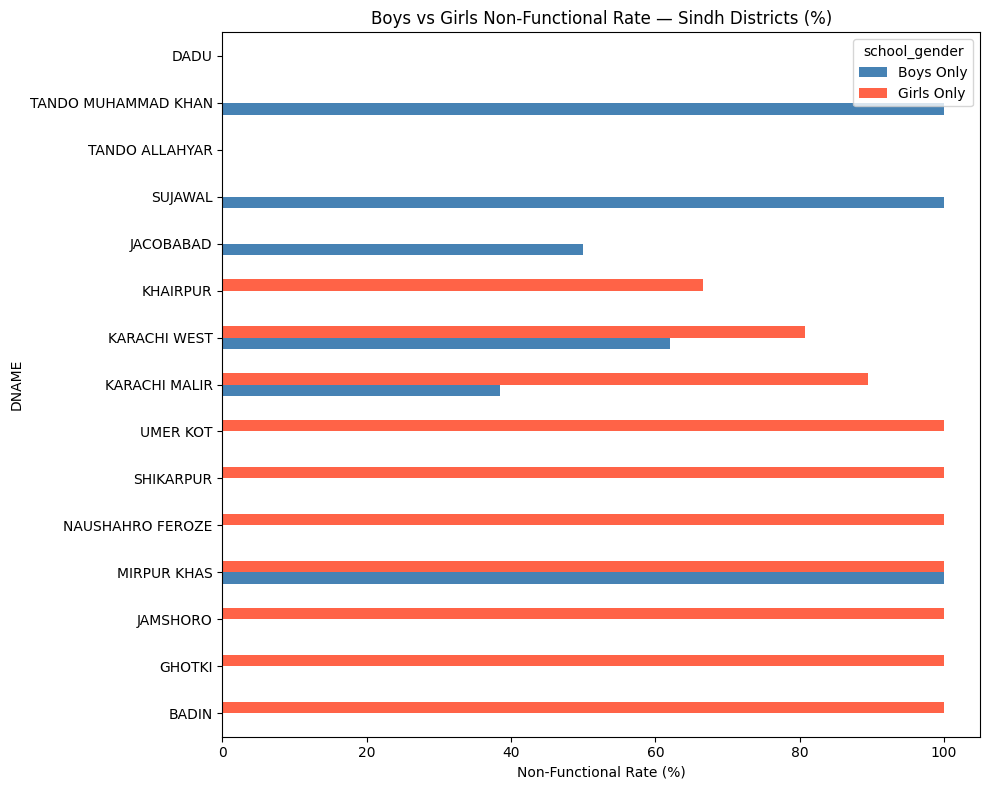

In [23]:
#plotting sindh district gender gap
top15 = sindh_dist_gender.sort_values('Girls Only', ascending=False).head(15)

top15[['Boys Only','Girls Only']].plot(kind='barh', figsize=(10,8),
                                        color=['steelblue','tomato'])
plt.title('Boys vs Girls Non-Functional Rate — Sindh Districts (%)')
plt.xlabel('Non-Functional Rate (%)')
plt.tight_layout()
plt.savefig('D:/pakistan-education-analysis/visuals/sindh_district_gender_gap.png', dpi=150)
plt.show()

## District Summary

In [24]:
#district level summary — all provinces
district_summary = df.groupby(['RNAME','DNAME']).agg(
    total_schools = ('nonfunctional','count'),
    nonfunctional_count = ('nonfunctional','sum'),
    nonfunctional_rate = ('nonfunctional','mean')
).reset_index()

district_summary['nonfunctional_rate'] = (district_summary['nonfunctional_rate'] * 100).round(1)
district_summary.sort_values('nonfunctional_rate', ascending=False).head(10)

,RNAME,DNAME,total_schools,nonfunctional_count,nonfunctional_rate
24,BALOCHISTAN ...,KHARAN,32,31,96.9
120,PUNJAB ...,SAHIWAL,31,30,96.8
27,BALOCHISTAN ...,KOHLU,33,31,93.9
109,PUNJAB ...,MANDI BAHAUDDIN,58,51,87.9
94,PUNJAB ...,BHAKKAR,8,7,87.5
95,PUNJAB ...,CHAKWAL,37,32,86.5
55,GILGIT-BALTISTAN ...,SKARDU,48,41,85.4
5,AZAD JAMMU AND KASHMIR ...,MIRPUR,50,42,84.0
91,PUNJAB ...,ATTOCK,57,47,82.5
124,PUNJAB ...,TOBA TEK SINGH,55,44,80.0


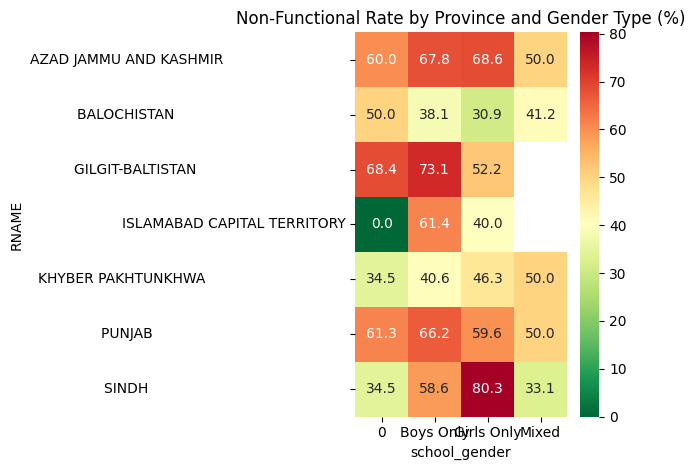

In [25]:
#heatmap — province vs gender type
heatmap_data = df.pivot_table(values='nonfunctional', index='RNAME',
                               columns='school_gender', aggfunc='mean') * 100

sns.heatmap(heatmap_data.round(1), annot=True, fmt='.1f', cmap='RdYlGn_r')
plt.title('Non-Functional Rate by Province and Gender Type (%)')
plt.tight_layout()
plt.savefig('D:/pakistan-education-analysis/visuals/province_gender_heatmap.png', dpi=150)
plt.show()

## Choropleth Map

In [26]:
#downloading pakistan district boundaries
import urllib.request, os

url = 'https://geodata.ucdavis.edu/gadm/gadm4.1/json/gadm41_PAK_2.json'
path = 'D:/pakistan-education-analysis/data/pakistan_districts.geojson'

if not os.path.exists(path):
    urllib.request.urlretrieve(url, path)
    print('downloaded!')
else:
    print('already exists')

downloaded!


In [27]:
#loading geojson
import geopandas as gpd
gdf = gpd.read_file(path)
gdf.shape

(32, 14)

In [29]:
gdf[['NAME_1','NAME_2']].head(10)

,NAME_1,NAME_2
0,AzadKashmir,AzadKashmir
1,Balochistan,Kalat
2,Balochistan,Makran
3,Balochistan,Nasirabad
4,Balochistan,Quetta
5,Balochistan,Sibi
6,Balochistan,Zhob
7,FederallyAdministeredTribalAr,F.A.T.A.
8,Gilgit-Baltistan,NorthernAreas
9,Islamabad,Islamabad


In [30]:
#merging district summary with geojson
gdf['district_clean'] = gdf['NAME_2'].str.strip().str.lower()
district_summary['district_clean'] = district_summary['DNAME'].str.strip().str.lower()

merged = gdf.merge(district_summary[['district_clean','nonfunctional_rate']],
                   on='district_clean', how='left')

print(f'matched: {merged["nonfunctional_rate"].notna().sum()} / {len(merged)}')

matched: 19 / 32


In [31]:
#creating the choropleth map
m = folium.Map(location=[30.3753, 69.3451], zoom_start=6, tiles='CartoDB positron')

folium.Choropleth(
    geo_data=merged,
    data=merged[merged['nonfunctional_rate'].notna()],
    columns=['NAME_2','nonfunctional_rate'],
    key_on='feature.properties.NAME_2',
    fill_color='RdYlGn_r',
    fill_opacity=0.75,
    line_opacity=0.3,
    nan_fill_color='lightgrey',
    legend_name='Non-Functional School Rate (%)'
).add_to(m)

m.save('D:/pakistan-education-analysis/visuals/pakistan_schools_map.html')
print('map saved!')
m

map saved!


## Saving District Summary

In [32]:
#saving district summary
district_summary.to_csv('D:/pakistan-education-analysis/data/district_summary.csv', index=False)
print('saved: district_summary.csv')

saved: district_summary.csv
